# Lab 09 — XGBoost: Feature Engineering, Hyperparameter Tuning, and Model Evaluation

## Learning goals

- Extract and engineer features from raw datetime and spatial variables
- Apply cyclical (sin/cos) encoding to temporal features
- Fit an XGBoost regression model to predict trip duration
- Understand the regularized XGBoost objective (L1, L2, gamma)
- Tune hyperparameters using randomized search with cross-validation and early stopping
- Evaluate models with regression metrics, diagnostic plots, and partial dependence plots

## Lab description

For this lab we use the **Toronto Bike Share** open ridership dataset for **May 2024**. The modelling task is **regression**: predict `trip_duration_min` from temporal and spatial features.

## Deliverables

Questions 1–4 answered, notebook and pdf uploaded to Quercus

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests, zipfile, io

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     RandomizedSearchCV)
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')


## Load and prepare data

Run the cells below — these are provided for you.

In [2]:
base_url = "https://ckan0.cf.opendata.inter.prod-toronto.ca"
package = requests.get(base_url + "/api/3/action/package_show",
    params={"id": "bike-share-toronto-ridership-data"}).json()

for r in package["result"]["resources"]:
    if "2024" in r["name"]:
        url_2024 = r["url"]
        break

resp = requests.get(url_2024)
z = zipfile.ZipFile(io.BytesIO(resp.content))
all_csvs = sorted(f for f in z.namelist() if f.endswith('.csv'))
print("Files in ZIP:", all_csvs)
may_files = all_csvs[4:5]
print("Loading:", may_files)

bike = pd.read_csv(z.open(may_files[0]), encoding='latin-1')
print(f"Shape: {bike.shape}")
bike.head(3)


Files in ZIP: ['Bike share ridership 2024-01.csv', 'Bike share ridership 2024-02.csv', 'Bike share ridership 2024-03.csv', 'Bike share ridership 2024-04.csv', 'Bike share ridership 2024-05.csv', 'Bike share ridership 2024-06.csv', 'Bike share ridership 2024-07.csv', 'Bike share ridership 2024-08.csv', 'Bike share ridership 2024-09.csv']
Loading: ['Bike share ridership 2024-05.csv']
Shape: (685782, 11)


,Trip Id,Trip Duration,Start Station Id,Start Time,Start Station Name,End Station Id,End Time,End Station Name,Bike Id,User Type,Model
0,28039944,2583,7633,05/01/2024 00:00,Noble St / Queen St W,7548,05/01/2024 00:43,St. Joseph St / Bay St - SMART,3227,Casual Member,ICONIC
1,28039945,666,7032,05/01/2024 00:00,Augusta Ave / Dundas St W,7163,05/01/2024 00:11,Yonge St / Wood St,3919,Casual Member,ICONIC
2,28039947,1574,7324,05/01/2024 00:00,King St W / Charlotte St,7237,05/01/2024 00:26,Ward St / Wallace Ave,5964,Casual Member,ICONIC


In [3]:
bike.columns = (bike.columns.str.strip()
                             .str.replace(r'\s+', '_', regex=True)
                             .str.lower())
bike['start_time']        = pd.to_datetime(bike['start_time'])
bike['trip_duration_min'] = bike['trip_duration'] / 60
bike['is_member']         = (bike['user_type'] == 'Annual Member').astype(int)
bike = bike[(bike['trip_duration_min'] >= 1) & (bike['trip_duration_min'] <= 120)]
print(f"Rows after filtering: {bike.shape[0]:,}")
print(f"Member rate: {bike['is_member'].mean():.1%}")
print("Columns:", list(bike.columns))


Rows after filtering: 679,831
Member rate: 12.9%
Columns: ['trip_id', 'trip_duration', 'start_station_id', 'start_time', 'start_station_name', 'end_station_id', 'end_time', 'end_station_name', 'bike_id', 'user_type', 'model', 'trip_duration_min', 'is_member']


In [4]:
stations = pd.DataFrame(
    requests.get('https://tor.publicbikesystem.net/ube/gbfs/v1/en/station_information')
    .json()['data']['stations'])[['station_id', 'lat', 'lon', 'capacity']]
stations['station_id'] = stations['station_id'].astype(int)
bike = bike.merge(stations, left_on='start_station_id', right_on='station_id', how='left')
print(f"Stations matched: {bike['lat'].notna().sum():,} / {len(bike):,}")


Stations matched: 658,461 / 679,831


In [5]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = np.radians(lat2 - lat1); dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1))*np.cos(np.radians(lat2))*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))


---

## Question 1: Feature Engineering

### 1a) Extract temporal features

Using `bike['start_time']` (already parsed to datetime), extract the following and add to `bike`:

| Column | Description |
|---|---|
| `hour` | Hour of day (0–23) |
| `day_of_week` | Day of week (0=Mon, 6=Sun) |
| `month` | Month (1–12) |
| `is_weekend` | 1 if Saturday or Sunday, else 0 |

Print the first 6 rows of these four columns alongside `start_time`.

In [6]:
# TODO: extract temporal features from start_time
bike['hour'] = bike['start_time'].dt.hour  # hint: derive hour-of-day from datetime accessors
bike['day_of_week'] = bike['start_time'].dt.dayofweek  # hint: derive weekday index (Mon=0 ... Sun=6)
bike['month'] = bike['start_time'].dt.month  # hint: derive calendar month from datetime values
bike['is_weekend'] = (bike['day_of_week'] >= 5).astype(int)  # hint: build a binary flag using weekday logic

# TODO: print first 6 rows with requested columns
display_cols = ['start_time', 'hour', 'day_of_week', 'month', 'is_weekend']  # hint: include exactly these columns in this order
print(bike[display_cols].head(6))


  start_time  hour  day_of_week  month  is_weekend
0 2024-05-01     0            2      5           0
1 2024-05-01     0            2      5           0
2 2024-05-01     0            2      5           0
3 2024-05-01     0            2      5           0
4 2024-05-01     0            2      5           0
5 2024-05-01     0            2      5           0


### 1b) Cyclical encoding

Raw integer values like `hour` (0–23) have a discontinuity: hour 23 and hour 0 are adjacent in time but far apart numerically. Apply **sine and cosine** transforms to `hour`, `day_of_week`, and `month` to preserve wrap-around structure.

For a variable with period $T$:

$$\sin\!\left(\frac{2\pi x}{T}\right), \quad \cos\!\left(\frac{2\pi x}{T}\right)$$

Add the six encoded columns to `bike` and print the first 4 rows of `['hour', 'hour_sin', 'hour_cos']`.

In [7]:
# TODO: cyclical encoding for hour, day_of_week, month
bike['hour_sin'] = np.sin(2 * np.pi * bike['hour'] / 24) # hint: apply sine transform with 24-hour period
bike['hour_cos'] = np.cos(2 * np.pi * bike['hour'] / 24)  # hint: apply cosine transform with 24-hour period
bike['dow_sin'] = np.sin(2 * np.pi * bike['day_of_week'] / 7)  # hint: apply sine transform with weekly period
bike['dow_cos'] = np.cos(2 * np.pi * bike['day_of_week'] / 7)  # hint: apply cosine transform with weekly period
bike['month_sin'] = np.sin(2 * np.pi * bike['month'] / 12) # hint: apply sine transform with yearly month cycle
bike['month_cos'] = np.cos(2 * np.pi * bike['month'] / 12) # hint: apply cosine transform with yearly month cycle

# print preview
print(bike[['hour', 'hour_sin', 'hour_cos']].head(4))


   hour  hour_sin  hour_cos
0     0       0.0       1.0
1     0       0.0       1.0
2     0       0.0       1.0
3     0       0.0       1.0


### 1c) Distance to the CN Tower

Using the provided `haversine_km` function, compute the great-circle distance (in km) from each trip's start station to the **CN Tower** (lat = 43.6426, lon = −79.3871). Add the result as `bike['dist_cn_tower_km']` and print the first 4 rows showing `start_station_id`, `lat`, `lon`, and `dist_cn_tower_km`.

In [8]:
CN_TOWER_LAT, CN_TOWER_LON = 43.6426, -79.3871

# TODO: compute distance from each start station to CN Tower
bike['dist_cn_tower_km'] = haversine_km(
    bike['lat'], bike['lon'], CN_TOWER_LAT, CN_TOWER_LON)  # hint: pass station lat/lon arrays plus fixed CN Tower coordinates to the helper

# TODO: print first 4 rows with required columns
print_cols = ['start_station_id', 'lat', 'lon', 'dist_cn_tower_km']  # hint: same fields requested in the prompt
print(bike[print_cols].head(4))


   start_station_id        lat        lon  dist_cn_tower_km
0              7633  43.642269 -79.429210          3.388666
1              7032  43.652473 -79.401456          1.593569
2              7324  43.645572 -79.393990          0.645427
3              7633  43.642269 -79.429210          3.388666


### 1d) Assemble the feature matrix

Complete `build_features` to return a DataFrame with:

- `is_weekend`, `is_member` — binary flags
- `hour_sin`, `hour_cos`, `dow_sin`, `dow_cos`, `month_sin`, `month_cos` — cyclical encodings
- `dist_cn_tower_km`, `capacity` — spatial features

Create `X` and `y_reg = bike['trip_duration_min']`. Print the feature count and column names.

In [9]:
def build_features(df):
    out = pd.DataFrame(index=df.index)
    
    # TODO: add binary features
    out['is_weekend'] = df['is_weekend'].copy()  # hint: copy over the prepared weekend indicator
    out['is_member'] = df['is_member'].copy()  # hint: copy over the prepared membership indicator
    
    # TODO: add cyclical features
    out['hour_sin'] = df['hour_sin'].copy()  # hint: include transformed hour signal
    out['hour_cos'] = df['hour_cos'].copy()  # hint: include transformed hour signal
    out['dow_sin'] = df['dow_sin'].copy()  # hint: include transformed weekday signal
    out['dow_cos'] = df['dow_cos'].copy()  # hint: include transformed weekday signal
    out['month_sin'] = df['month_sin'].copy()  # hint: include transformed month signal
    out['month_cos'] = df['month_cos'].copy()  # hint: include transformed month signal
    
    # TODO: add spatial features
    out['dist_cn_tower_km'] = df['dist_cn_tower_km'].copy()  # hint: include engineered distance feature
    out['capacity'] = df['capacity'].copy()  # hint: include station capacity as numeric predictor

    return out

X = build_features(bike)
y_reg = bike['trip_duration_min']  # hint: use trip duration in minutes as the regression target
print(f'Features: {X.shape[1]}')
print('Columns:', list(X.columns))


Features: 10
Columns: ['is_weekend', 'is_member', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'dist_cn_tower_km', 'capacity']


### 1e) Data leakage

The raw dataset contains `end_time` and `end_station_id`. Explain in 1–2 sentences why including these as predictors of `trip_duration_min` would constitute **data leakage**, and why the features in 1d) are safe.

*Solution:*

To avoid data leakage, we should only keep features that could be know at the time of prediction, before observing the outcome. Therefore, we should not include `end_time` and `end_station_id` as predictors of `trip_duration_min` because they are not known at the time of prediction, since `end_time` is start_time + duration which directly leaks the outcome and `end_station_id` can only be known after observing the outcome.

---

## Question 2: Baseline XGBoost Model

### 2a) Train/test split and baseline fit

Split the data into training (70%) and test (30%) sets using `random_state=65`. Fit a baseline `XGBRegressor` with `n_estimators=200`, `max_depth=5`, `learning_rate=0.1`, and `importance_type='gain'`. Report test RMSE and R².

In [ ]:
# TODO: split data (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.3, random_state=65)  # hint: create a reproducible 70/30 split with random_state=65
print(f"Training rows: {X_train.shape[0]:,} | Test rows: {X_test.shape[0]:,}")

# TODO: define baseline model
xgb_base = XGBRegressor(
    n_estimators=200,  # hint: set the number of boosting rounds from the prompt
    max_depth=5,  # hint: set tree depth from the prompt
    learning_rate=0.1,  # hint: set step size from the prompt
    importance_type='gain',
    random_state=65,
    n_jobs=-1
 )

# TODO: fit model and predict
xgb_base.fit(X_train, y_train)  # hint: train on training features/labels
y_pred_base = xgb_base.predict(X_test)  # hint: generate predictions on the test feature matrix

# TODO: compute metrics
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))  # hint: compute root mean squared error on test predictions
r2_base = r2_score(y_test, y_pred_base)  # hint: compute coefficient of determination on test predictions
print(f'Baseline — RMSE: {rmse_base:.2f} min  | R2: {r2_base:.4f}')


Training rows: 475,881 | Test rows: 203,950
Baseline — RMSE: 13.54 min  | R2: 0.1510


### 2b) Feature importance

Plot a horizontal bar chart of feature importances (gain) for the baseline model. Which features are most important? Does the ranking make intuitive sense?

*Interpretation:*

The most important features are `is_member`, `dist_cn_tower_km`, `is_weekend`, `capacity`, and `hour_sin`. This ranking makes intuitive sense because membership status and the distance to the CN Tower can strongly reflect typical trip purpose and behavior, weekends often have different riding patterns than weekdays, and station capacity captures some differences in station sizes. Time of the day matters too, even that is not much but peak or off-peak hours can have different trip durations.

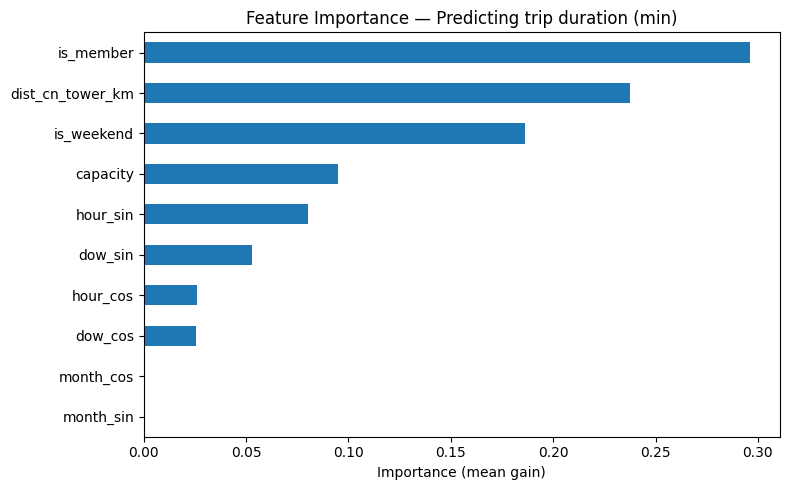

Top 5 features: {'is_member': 0.29598143696784973, 'dist_cn_tower_km': 0.23746848106384277, 'is_weekend': 0.18640518188476562, 'capacity': 0.09490882605314255, 'hour_sin': 0.08027429133653641}


In [ ]:
# TODO: compute feature importances from fitted baseline model
imp = pd.Series(xgb_base.feature_importances_, index=X.columns)  # hint: build a labeled 1D structure mapping feature names to model importances

# TODO: horizontal bar chart
fig, ax = plt.subplots(figsize=(8, 5))
imp.sort_values().plot(kind='barh', ax=ax)  # hint: sort importances and plot as horizontal bars
ax.set_xlabel('Importance (mean gain)')
ax.set_title('Feature Importance — Predicting trip duration (min)')
plt.tight_layout(); plt.show()

# Optional check
top5 = imp.sort_values(ascending=False).head(5).to_dict()  # hint: extract the five highest-importance features as a compact summary
print('Top 5 features:', top5)


---

## Question 3: Hyperparameter Tuning

### 3a) Bias-variance tradeoff

Train an `XGBRegressor` with `n_estimators=600`, `max_depth=5`, `learning_rate=0.1`. Using `iteration_range`, compute training and test RMSE at every 10 rounds from 10 to 600. Plot both curves. At roughly what round does test RMSE stop improving? Note this takes about 1 minute to run.

*Solution:*

Around 300 rounds.

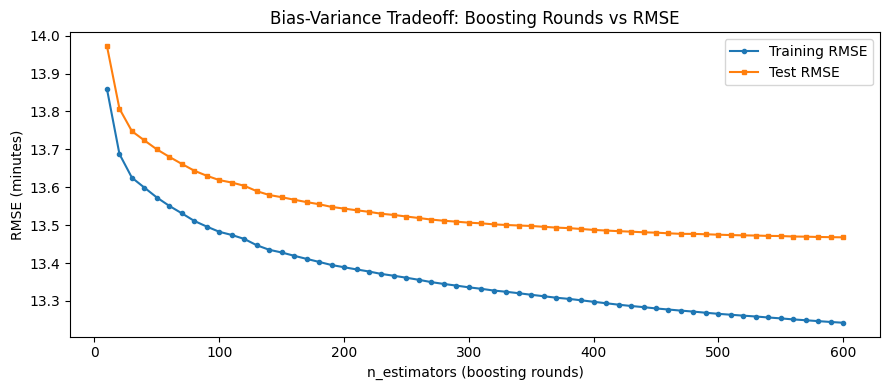

Approximate best round: 600 (test RMSE: 13.468 min)


In [ ]:
# TODO: train model for bias-variance curve
xgb_bv = XGBRegressor(
    n_estimators=600,  # hint: use a large round count so you can inspect overfitting behavior
    max_depth=5,  # hint: keep depth fixed as instructed
    learning_rate=0.1,  # hint: keep learning rate fixed as instructed
    random_state=65,
    n_jobs=-1
 )
xgb_bv.fit(X_train, y_train)  # hint: fit once on training data before evaluating by iteration range

n_rounds = list(range(10, 610, 10))
train_err, test_err = [], []

# TODO: compute RMSE at each round using iteration_range=(0, n)
for n in n_rounds:
    tr_pred = xgb_bv.predict(X_train, iteration_range=(0, n))  # hint: predict using only the first n boosting rounds on training data
    te_pred = xgb_bv.predict(X_test, iteration_range=(0, n))  # hint: predict using only the first n boosting rounds on test data
    train_rmse_n = np.sqrt(mean_squared_error(y_train, tr_pred))  # hint: calculate RMSE for training predictions at round n
    test_rmse_n = np.sqrt(mean_squared_error(y_test, te_pred))  # hint: calculate RMSE for test predictions at round n
    train_err.append(train_rmse_n)
    test_err.append(test_rmse_n)

# TODO: plot curves
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(n_rounds, train_err, 'o-', label='Training RMSE', markersize=3)
ax.plot(n_rounds, test_err,  's-', label='Test RMSE', markersize=3)
ax.set_xlabel('n_estimators (boosting rounds)')
ax.set_ylabel('RMSE (minutes)')
ax.set_title('Bias-Variance Tradeoff: Boosting Rounds vs RMSE')
ax.legend()
plt.tight_layout(); plt.show()

best_n = n_rounds[int(np.argmin(test_err))]  # hint: pick the round index where test error is minimal
best_test_rmse = min(test_err)  # hint: take the minimum value from the test RMSE list
print(f'Approximate best round: {best_n} (test RMSE: {best_test_rmse:.3f} min)')


### 3b) Randomized search with cross-validation

XGBoost minimizes a regularized objective:

$$\mathcal{L} = \sum_i \ell(y_i, \hat{y}_i) + \sum_k \left[ \gamma T_k + \tfrac{1}{2}\lambda \|w_k\|^2 + \alpha \|w_k\|_1 \right]$$

Use `RandomizedSearchCV` with 5-fold CV on the **training set** to tune `max_depth`, `learning_rate`, `reg_lambda` (L2), and `reg_alpha` (L1). Use `n_iter=20` and `scoring='neg_root_mean_squared_error'`. Print the best parameters and best CV RMSE.

*Note: the full grid has $3^4 = 81$ combinations — random search samples 20, reducing compute from 405 to 100 fits.*

In [15]:
param_dist = {
    'max_depth':     [4,6,8],
    'learning_rate': [0.05, 0.1, 0.5],
    'reg_lambda':    [0.1, 1, 10],
    'reg_alpha':     [0, 0.1, 1],
}

# TODO: create base estimator for random search
xgb_rs = XGBRegressor(
    n_estimators=300,  # hint: choose a fixed boosting-round budget for each sampled config
    random_state=65,
    n_jobs=-1
 )

# TODO: set up RandomizedSearchCV (5-fold, n_iter=20, RMSE scoring)
rand_search = RandomizedSearchCV(
    estimator=xgb_rs,
    param_distributions=param_dist,
    n_iter=20,  # hint: number of random parameter samples to evaluate
    cv=5,  # hint: number of cross-validation folds
    scoring='neg_root_mean_squared_error',  # hint: use negative RMSE so larger is better to sklearn
    random_state=65,
    n_jobs=-1,
    verbose=1
 )

# TODO: fit on training data only
rand_search.fit(X_train, y_train)  # hint: run the randomized search on X_train/y_train

# TODO: print best params and best CV RMSE
best_params_found = rand_search.best_params_  # hint: retrieve selected hyperparameters from fitted search object
best_cv_rmse = -rand_search.best_score_  # hint: convert best score back to positive RMSE scale
print('Best params:', best_params_found)
print(f'Best CV RMSE: {best_cv_rmse:.2f} minutes')


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'reg_lambda': 10, 'reg_alpha': 0, 'max_depth': 8, 'learning_rate': 0.1}
Best CV RMSE: 13.35 minutes


### 3c) Early stopping for `n_estimators`

Split the training set into sub-train (80%) / validation (20%). Fit an `XGBRegressor` with `n_estimators=2000`, `max_depth=5`, `learning_rate=0.05`, `early_stopping_rounds=50`. Pass the validation set as `eval_set`. Report the best iteration and validation RMSE.

In [ ]:
# TODO: split training data into sub-train/validation
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=65)  # hint: carve out a validation subset from training data with fixed randomness

# TODO: configure model with early stopping
xgb_es = XGBRegressor(
    n_estimators=2000,  # hint: set a large upper bound so early stopping can decide where to stop
    max_depth=5,  # hint: use instructed tree depth
    learning_rate=0.05,  # hint: use instructed learning rate
    early_stopping_rounds=50,  # hint: patience before stopping when validation score stalls
    random_state=65,
    n_jobs=-1
 )

# TODO: fit with validation eval_set
xgb_es.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)  # hint: train with eval_set containing validation features/labels and suppress verbose logs

best_iter = xgb_es.best_iteration  # hint: read the best boosting iteration learned during early stopping
val_rmse = xgb_es.best_score  # hint: read the best validation RMSE reported by the model
print(f'Best round: {best_iter}')
print(f'Val RMSE:   {val_rmse:.2f} minutes')


Best round: 1367
Val RMSE:   13.30 minutes


Question: Briefly explain why we do early stopping.

**Solution:**

Early stopping prevents overfitting by terminating the training process when the validation error starts improving minimally, which also tunes `n_estimators` automatically.


### 3d) Fit the final tuned model

Using the best hyperparameters from 3b), fit a final `XGBRegressor` with `n_estimators=500` on the full training set. Report test RMSE and R². How does it compare to the baseline?

In [19]:
best_params = rand_search.best_params_  # uncomment if 3b was run
best_params = {'max_depth': 7, 'learning_rate': 0.3, 'reg_lambda': 10, 'reg_alpha': 0.1}

# TODO: fit final tuned model on full training set
xgb_best = XGBRegressor(
    n_estimators=500,  # hint: use the instructed round count for final comparison
    **best_params,
    random_state=65,
    n_jobs=-1
 )
xgb_best.fit(X_train, y_train)  # hint: fit tuned model on the full training split
y_pred_best = xgb_best.predict(X_test)  # hint: produce test-set predictions with tuned model

# TODO: evaluate tuned model
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_best))  # hint: compute test RMSE for tuned predictions
r2_tuned = r2_score(y_test, y_pred_best)  # hint: compute test R-squared for tuned predictions
print(f'Tuned — RMSE: {rmse_tuned:.2f} min  | R2: {r2_tuned:.4f}')
print(f'Improvement in RMSE: {rmse_base - rmse_tuned:.2f} min')


Tuned — RMSE: 13.45 min  | R2: 0.1632
Improvement in RMSE: 0.10 min


---

## Question 4: Model Evaluation

### 4a) Regression diagnostics

For the tuned model from 3d), create a two-panel figure:

- **Left**: predicted vs actual scatter plot with a 45° reference line
- **Right**: histogram of residuals (actual − predicted) with a vertical line at zero

Comment on any systematic patterns.

**Interpretation:**

The plots shows over esitmation for short trips and under esitmation for long trips (predictions shrink toward the mean). The residuals are centered near 0 but right-skewed, meaning some trips are substantially underestimated, so errors are not perfectly symmetric.

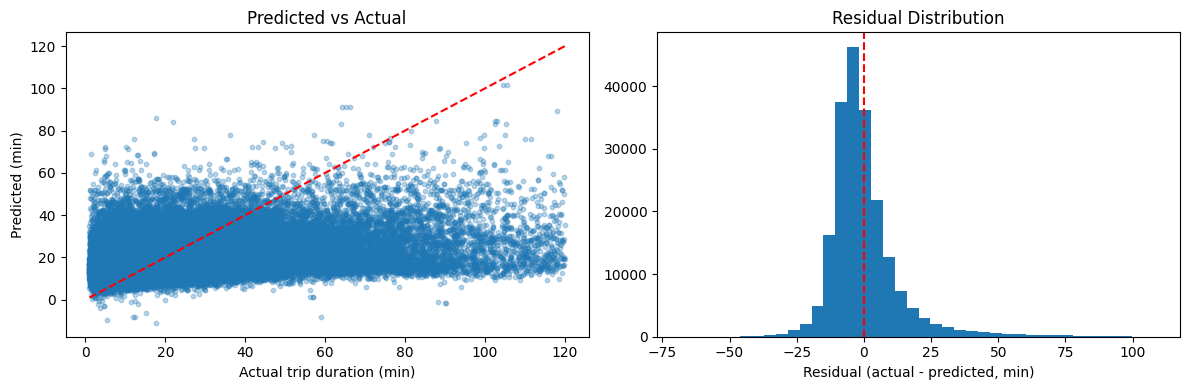

In [20]:
# TODO: regression diagnostics for tuned model
residuals = y_test - y_pred_best  # hint: compute actual minus predicted errors on the test set

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: predicted vs actual
axes[0].scatter(y_test, y_pred_best, alpha=0.3, s=10)  # hint: scatter true values vs predictions for test observations
mn, mx = y_test.min(), y_test.max()  # hint: use min/max of actual test target to define a diagonal reference
axes[0].plot([mn, mx], [mn, mx], 'r--')  # 45-degree line
axes[0].set_xlabel('Actual trip duration (min)')
axes[0].set_ylabel('Predicted (min)')
axes[0].set_title('Predicted vs Actual')

# Right panel: residual histogram
axes[1].hist(residuals, bins=40)  # hint: histogram the residual distribution with a reasonable bin count
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (actual - predicted, min)')
axes[1].set_title('Residual Distribution')

plt.tight_layout(); plt.show()


### 4b) Partial dependence plots

Use `PartialDependenceDisplay.from_estimator` to plot the marginal effect of `is_member`, `dist_cn_tower_km`, and `hour_sin` on predicted trip duration. Create a single figure with three side-by-side panels, one per feature.

*Hint: pass `X_train.sample(2000, random_state=65)` instead of the full training set to keep it fast.*

Interpret each panel: what does the model say about how each feature relates to trip duration?

**Interpretation:**

`is_member` shows members are predicted to have shorter trips in general.

`dist_cn_tower_km` generally increases, so farther from the CN Tower leads to longer predicted trips.

`hour_sin` trends slightly downward, which shows that some hours of day are predicted to have slightly shorter trips than others.

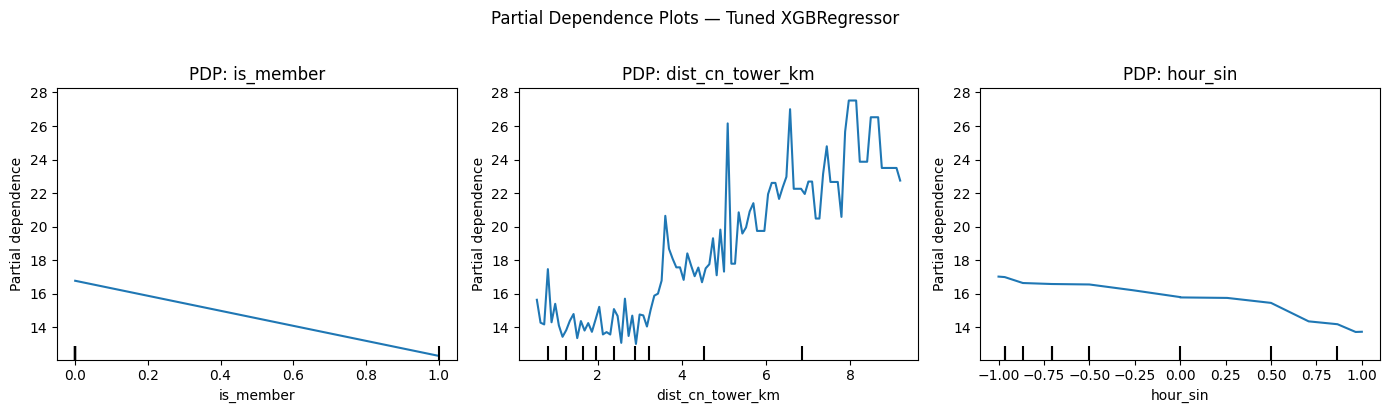

In [21]:
# TODO: PDPs for selected features using a sample for speed
sample_X = X_train.sample(2000, random_state=65)  # hint: draw a reproducible subset of training rows for faster plotting
features_to_plot = ['is_member', 'dist_cn_tower_km', 'hour_sin']  # hint: include membership, CN-tower distance, and encoded hour feature

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
PartialDependenceDisplay.from_estimator(xgb_best, sample_X, features_to_plot, ax=axes)  # hint: call PDP utility with estimator, sampled data, selected features, and provided axes
axes[0].set_title('PDP: is_member')
axes[1].set_title('PDP: dist_cn_tower_km')
axes[2].set_title('PDP: hour_sin')
plt.suptitle('Partial Dependence Plots — Tuned XGBRegressor', y=1.02)
plt.tight_layout(); plt.show()


### 4c) Cross-validation estimate

Use `cross_val_score` with 5-fold CV on the **training set** to estimate generalization RMSE for the tuned model. Compare to the test RMSE from 3d). Are they close?

**Interpretation:**

The 5-fold CV RMSE on the training set is close to the held-out test RMSE, with a difference of only 0.05 min. This suggests the tuned model’s performance is stable and similar across splits in general.


In [25]:
# TODO: cross-validation RMSE estimate on training set
xgb_cv = XGBRegressor(
    n_estimators=500,  # hint: match the tuned model's boosting-round setting
    **best_params,
    random_state=65,
    n_jobs=-1
 )

cv_scores = cross_val_score(xgb_cv, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')  # hint: run k-fold CV on training split using a negative-RMSE scoring option
cv_rmse = -cv_scores.mean()  # hint: convert mean CV score to positive RMSE

print(f'5-fold CV RMSE (training set): {cv_rmse:.2f} min')
print(f'Test RMSE:                     {rmse_tuned:.2f} min')
print(f'Difference:                    {abs(cv_rmse - rmse_tuned):.2f} min')


5-fold CV RMSE (training set): 13.40 min
Test RMSE:                     13.45 min
Difference:                    0.05 min


### 4d) Summary table

Fill in RMSE and R² for both models in the table below.

In [26]:
# TODO: fill model summary table with your computed metrics
summary = pd.DataFrame({
    'Model':           ['Baseline XGBRegressor', 'Tuned XGBRegressor'],
    'Test RMSE (min)': [13.54, 13.45],   # hint: plug in rounded baseline/tuned RMSE values
    'Test R2':         [0.151, 0.1632],   # hint: plug in rounded baseline/tuned R-squared values
})
print(summary.to_string(index=False))


                Model  Test RMSE (min)  Test R2
Baseline XGBRegressor            13.54   0.1510
   Tuned XGBRegressor            13.45   0.1632
